In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_excel("Supply Chain Dataset.xlsx")

In [4]:
data

,Order ID,Order Date,Delivery Date,Customer ID,Customer Name,Region,Warehouse,Product ID,Product Name,Category,...,Lead Time (Days),Order Status,Delivery Status,Delivery Days,On-Time Delivery,Vendor Rating,Unit Cost,Sales Amount,Profit,Inventory Status
0,O00001,2025-02-05,2025-02-13,C0317,Customer 1049,North,WH-B,P094,Product 193,Food,...,7,Cancelled,Delayed,8,No,4.5,400,187600,46601.76,In Stock
1,O00002,2025-02-14,2025-02-19,C0393,Customer 315,North,WH-C,P193,Product 2,Furniture,...,5,Pending,On Time,5,Yes,4.5,459,12852,2193.76,In Stock
2,O00003,2025-04-27,2025-05-04,C1129,Customer 1105,West,WH-C,P221,Product 239,Electronics,...,5,Delivered,Delayed,7,No,3.8,244,23424,4780.96,In Stock
3,O00004,2025-11-25,2025-12-04,C0816,Customer 34,South,WH-D,P208,Product 169,Food,...,8,Delivered,Delayed,9,No,3.3,297,83160,15182.68,In Stock
4,O00005,2025-02-21,2025-03-02,C0343,Customer 862,East,WH-B,P077,Product 208,Furniture,...,10,Delivered,On Time,9,Yes,4.9,493,223329,22052.11,In Stock
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4392,O04393,2025-03-16,2025-03-22,C0587,Customer 1187,North,WH-C,P165,Product 92,Food,...,7,Cancelled,On Time,6,Yes,4.0,63,10458,1716.92,In Stock
4393,O04394,2025-12-12,2025-12-20,C1116,Customer 656,East,WH-D,P080,Product 172,Office,...,9,Pending,On Time,8,Yes,3.8,400,11200,1570.19,In Stock
4394,O04395,2025-06-21,2025-07-04,C0362,Customer 80,South,WH-D,P069,Product 116,Furniture,...,10,Pending,Delayed,13,No,3.3,127,28448,3718.39,In Stock
4395,O04396,2025-10-13,2025-10-16,C1093,Customer 830,West,WH-B,P100,Product 133,Furniture,...,2,Pending,Delayed,3,No,4.8,195,39390,4204.44,In Stock


In [5]:
data.dtypes

Order ID                          str
Order Date             datetime64[us]
Delivery Date          datetime64[us]
Customer ID                       str
Customer Name                     str
Region                            str
Warehouse                         str
Product ID                        str
Product Name                      str
Category                          str
Vendor ID                         str
Vendor Name                       str
Order Quantity                  int64
Delivered Quantity              int64
Inventory Available             int64
Reorder Level                   int64
Lead Time (Days)                int64
Order Status                      str
Delivery Status                   str
Delivery Days                   int64
On-Time Delivery                  str
Vendor Rating                 float64
Unit Cost                       int64
Sales Amount                    int64
Profit                        float64
Inventory Status                  str
dtype: objec

In [10]:
data.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Order ID,4397,4397,O00001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Order Date,4397,NaN,NaN,NaN,2025-06-30 13:21:42.615419,2025-01-01 00:00:00,2025-03-31 00:00:00,2025-06-29 00:00:00,2025-10-02 00:00:00,2025-12-31 00:00:00,NaN
Delivery Date,4397,NaN,NaN,NaN,2025-07-07 13:31:12.458494,2025-01-04 00:00:00,2025-04-08 00:00:00,2025-07-04 00:00:00,2025-10-08 00:00:00,2026-01-13 00:00:00,NaN
Customer ID,4397,1166,C0768,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer Name,4397,1169,Customer 464,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Region,4397,4,South,1112,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Warehouse,4397,4,WH-B,1121,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product ID,4397,250,P227,28,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product Name,4397,250,Product 215,31,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Category,4397,4,Furniture,1124,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
numerical_col = ['Order Quantity','Delivered Quantity','Inventory Available','Reorder Level','Lead Time (Days)','Delivery Days','Vendor Rating','Unit Cost','Sales Amount','Profit']
summary = data[numerical_col].describe().T
summary['median'] = data[numerical_col].median()
summary

,count,mean,std,min,25%,50%,75%,max,median
Order Quantity,4397.0,256.197180,142.045958,10.00,134.00,254.00,382.00,500.00,254.00
Delivered Quantity,4397.0,246.124176,142.178611,0.00,124.00,244.00,371.00,499.00,244.00
Inventory Available,4397.0,503.547191,286.424237,0.00,256.00,507.00,749.00,1000.00,507.00
Reorder Level,4397.0,125.041619,43.713512,50.00,86.00,126.00,163.00,200.00,126.00
Lead Time (Days),4397.0,5.989766,2.598581,2.00,4.00,6.00,8.00,10.00,6.00
Delivery Days,4397.0,7.006595,2.924622,1.00,5.00,7.00,9.00,13.00,7.00
Vendor Rating,4397.0,3.987582,0.579856,3.00,3.50,4.00,4.50,5.00,4.00
Unit Cost,4397.0,253.878781,142.086379,10.00,129.00,253.00,377.00,500.00,253.00
Sales Amount,4397.0,65306.513759,55462.231938,156.00,19152.00,49455.00,98010.00,242550.00,49455.00
Profit,4397.0,10777.016259,9973.696333,16.79,2998.59,7722.83,15706.44,59497.87,7722.83


In [13]:
print(f"\nDuplicate rows: {data.duplicated().sum()}")
print(f"Duplicate Order IDs: {data['Order ID'].duplicated().sum()}")
data.isnull().sum()


Duplicate rows: 0
Duplicate Order IDs: 0


Order ID               0
Order Date             0
Delivery Date          0
Customer ID            0
Customer Name          0
Region                 0
Warehouse              0
Product ID             0
Product Name           0
Category               0
Vendor ID              0
Vendor Name            0
Order Quantity         0
Delivered Quantity     0
Inventory Available    0
Reorder Level          0
Lead Time (Days)       0
Order Status           0
Delivery Status        0
Delivery Days          0
On-Time Delivery       0
Vendor Rating          0
Unit Cost              0
Sales Amount           0
Profit                 0
Inventory Status       0
dtype: int64

In [9]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4397 entries, 0 to 4396
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Order ID             4397 non-null   str           
 1   Order Date           4397 non-null   datetime64[us]
 2   Delivery Date        4397 non-null   datetime64[us]
 3   Customer ID          4397 non-null   str           
 4   Customer Name        4397 non-null   str           
 5   Region               4397 non-null   str           
 6   Warehouse            4397 non-null   str           
 7   Product ID           4397 non-null   str           
 8   Product Name         4397 non-null   str           
 9   Category             4397 non-null   str           
 10  Vendor ID            4397 non-null   str           
 11  Vendor Name          4397 non-null   str           
 12  Order Quantity       4397 non-null   int64         
 13  Delivered Quantity   4397 non-null   int64  

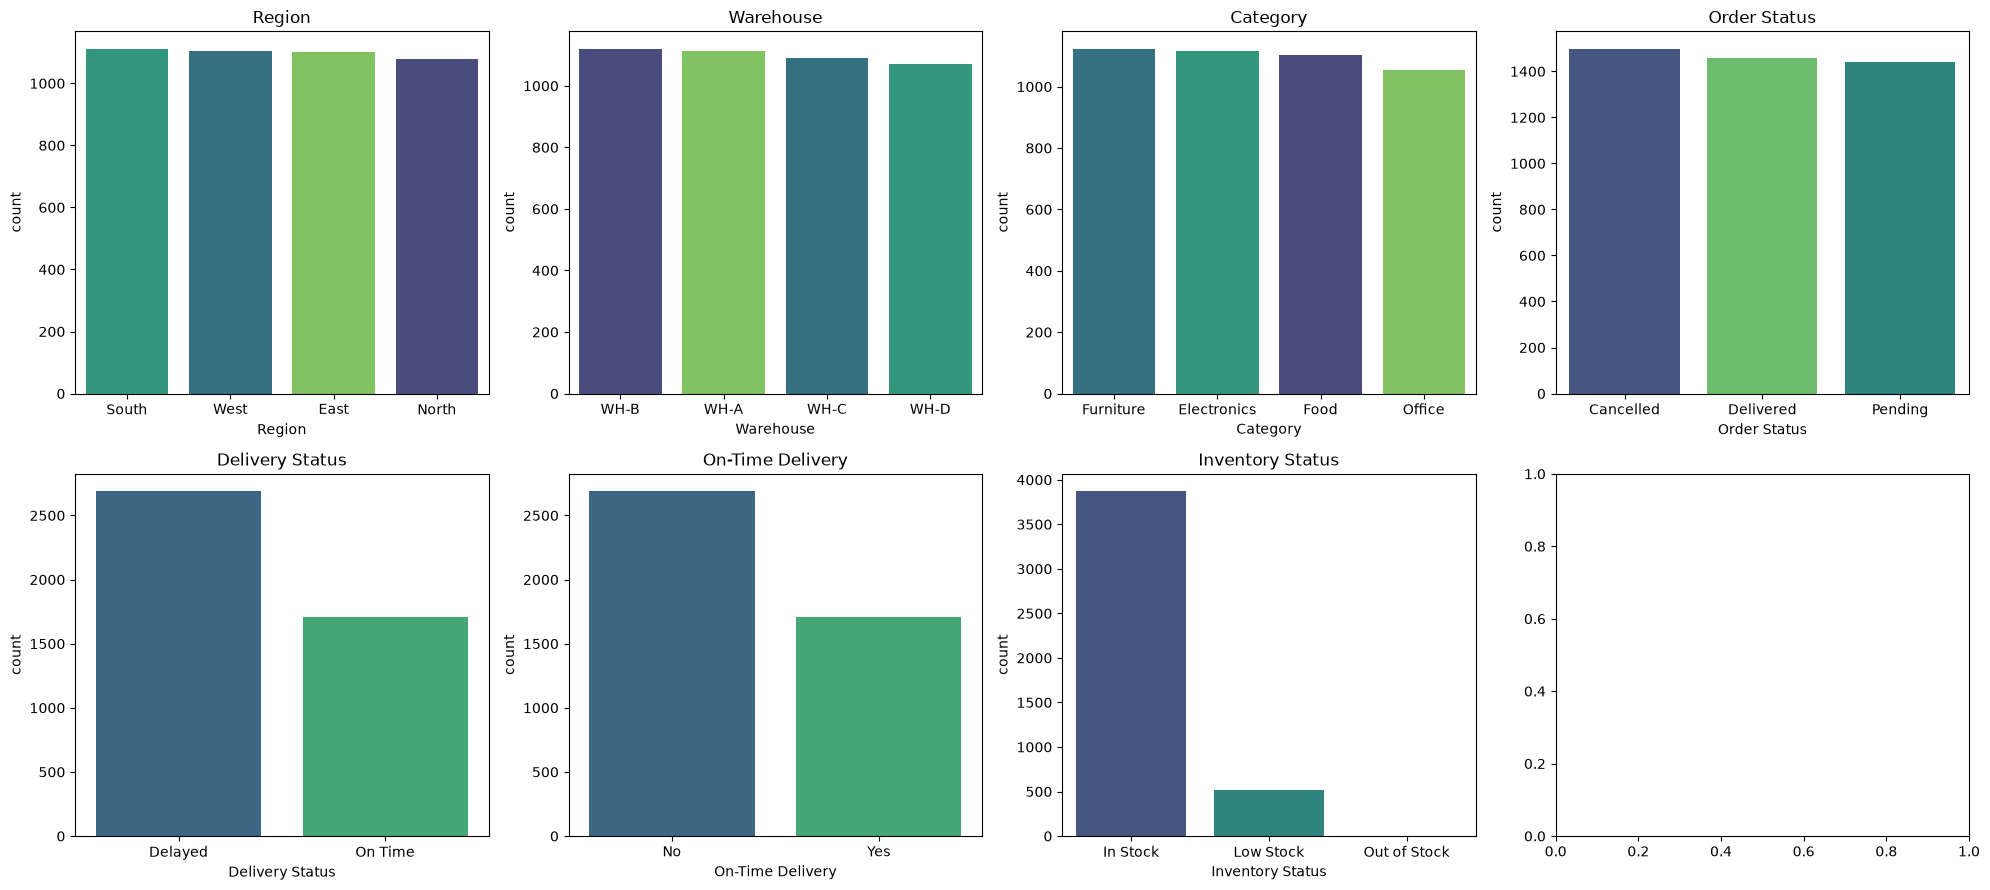

In [17]:
categorical_cols = ['Region', 'Warehouse', 'Category', 'Order Status',
                    'Delivery Status', 'On-Time Delivery', 'Inventory Status']

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()
for i, col in enumerate(categorical_cols):
    order = data[col].value_counts().index
    sns.countplot(data=data, x=col, order=order, ax=axes[i], hue=col, palette='viridis', legend=False)
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

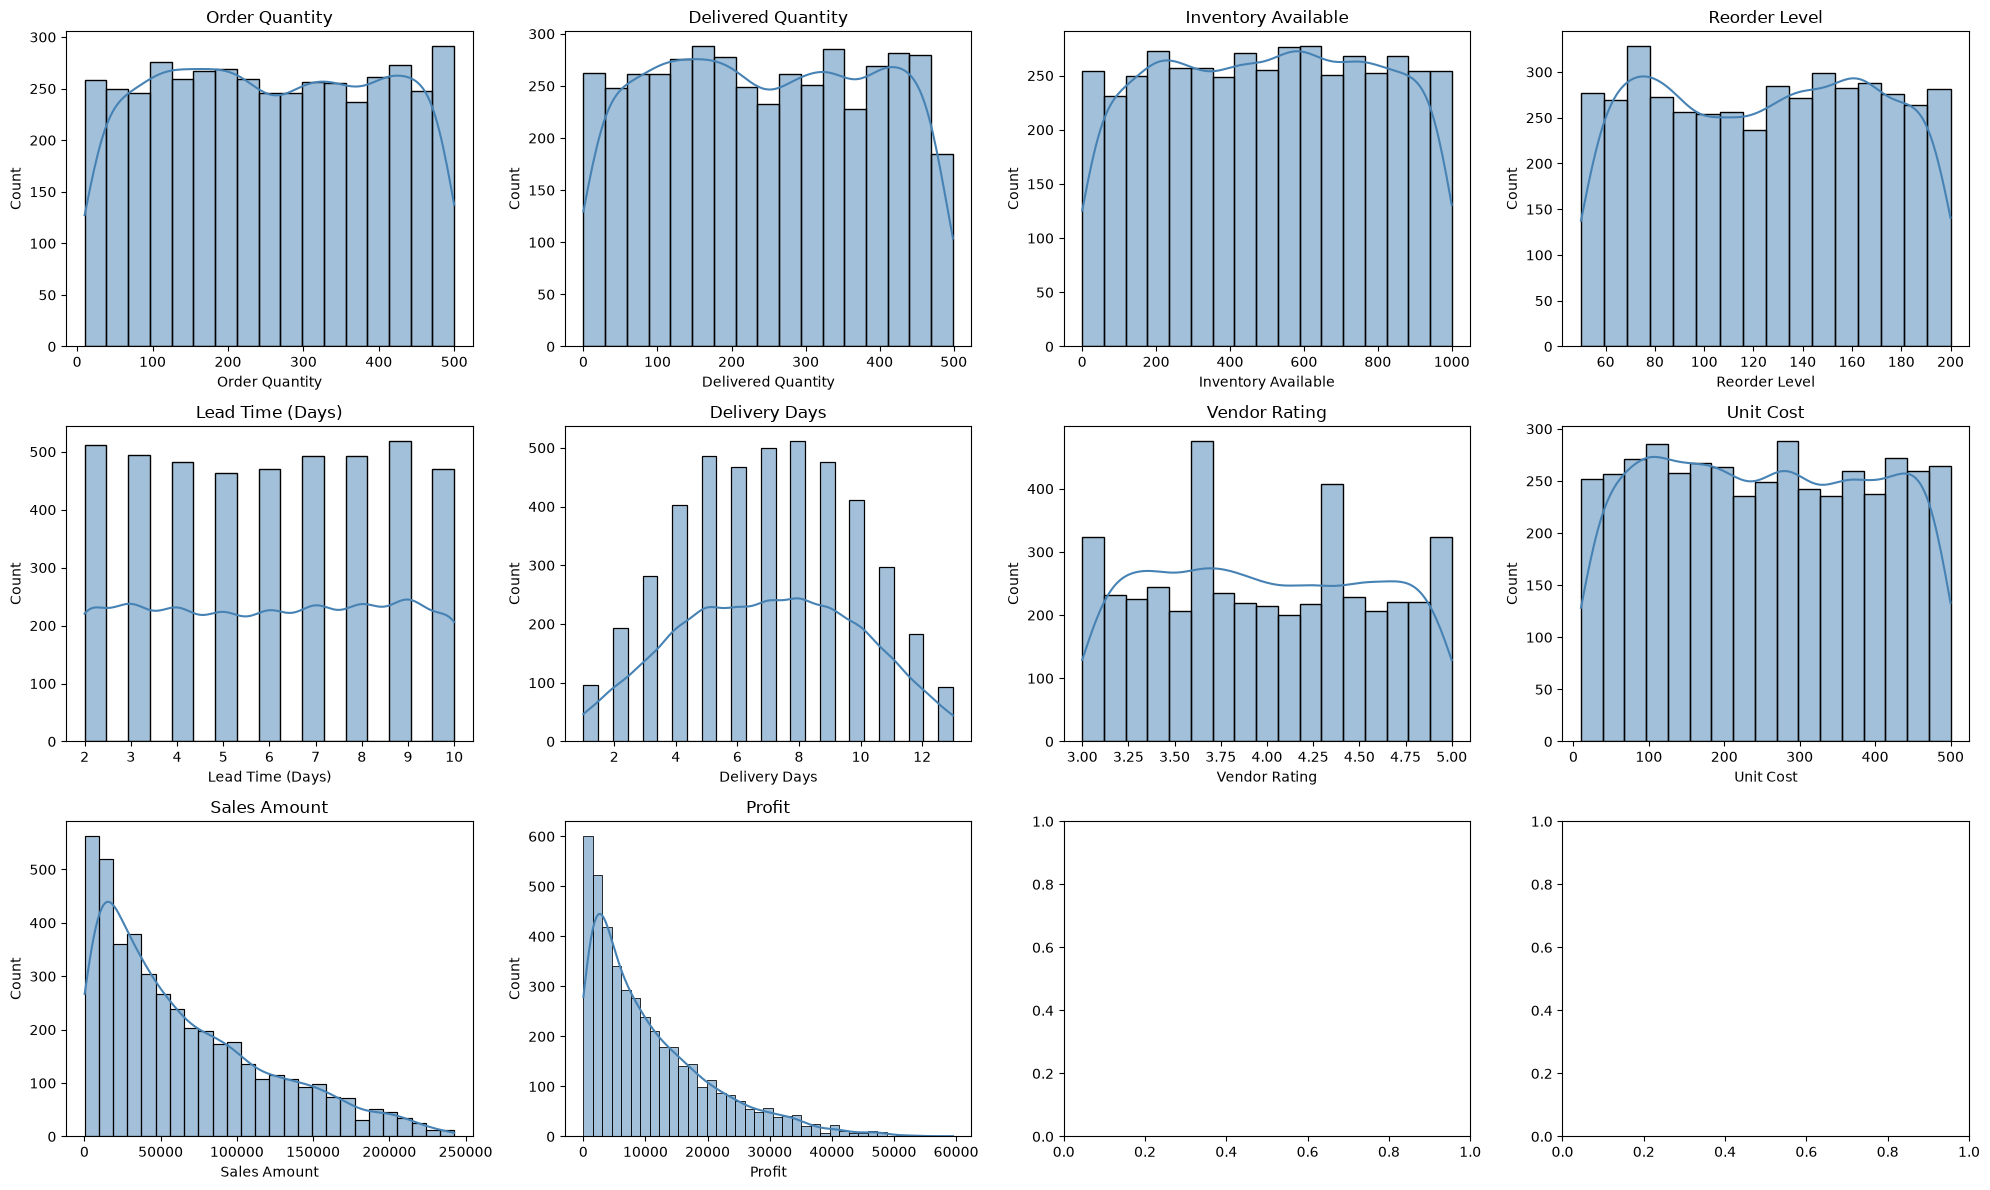

In [22]:
numeric_cols = ['Order Quantity', 'Delivered Quantity', 'Inventory Available',
                 'Reorder Level', 'Lead Time (Days)', 'Delivery Days',
                 'Vendor Rating', 'Unit Cost', 'Sales Amount', 'Profit']

fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.histplot(data[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

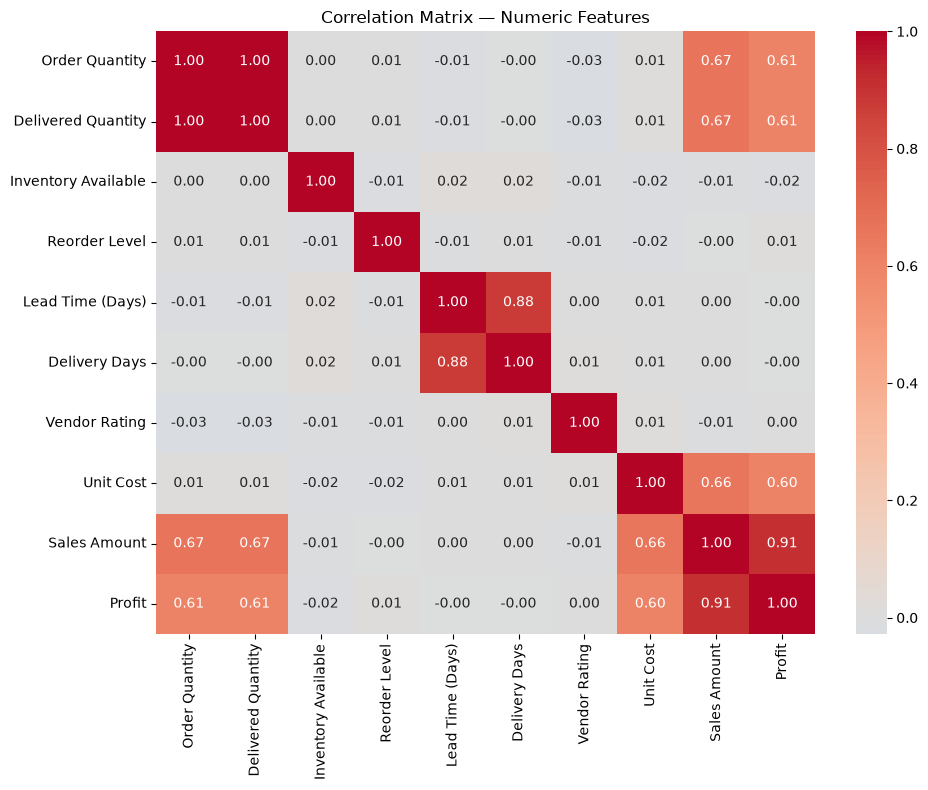

In [24]:
corr_cols = ['Order Quantity', 'Delivered Quantity', 'Inventory Available',
             'Reorder Level', 'Lead Time (Days)', 'Delivery Days',
             'Vendor Rating', 'Unit Cost', 'Sales Amount', 'Profit']

plt.figure(figsize=(10, 8))
sns.heatmap(data[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix — Numeric Features')
plt.tight_layout()
plt.show()


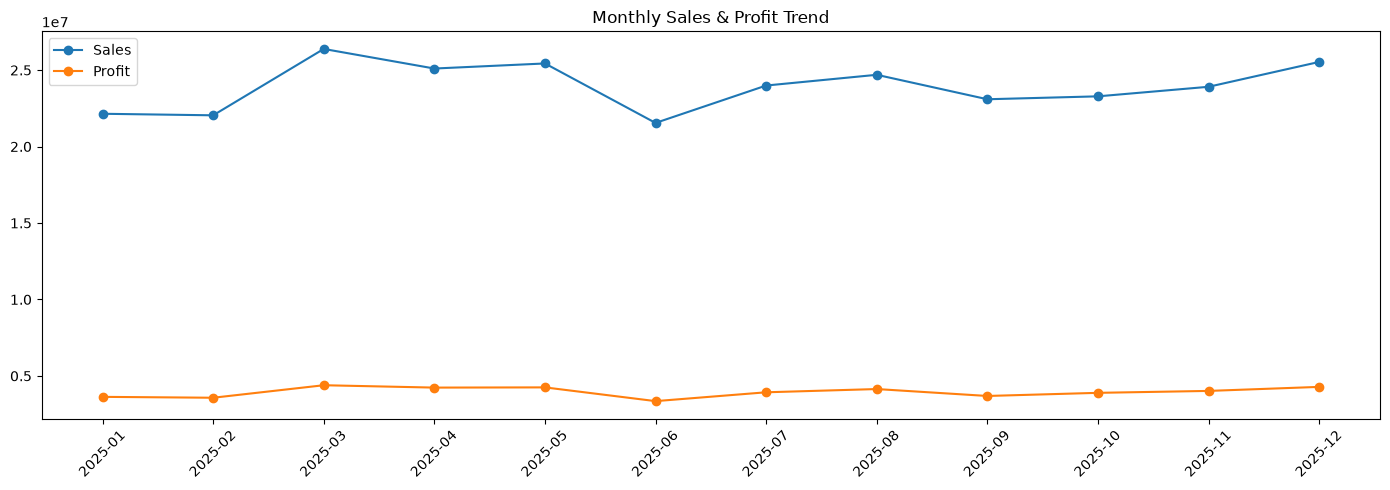

In [29]:
data['Order Month'] = data['Order Date'].dt.to_period('M').astype(str)
monthly = data.groupby('Order Month').agg(Total_Sales=('Sales Amount', 'sum'),
                                          Total_Profit=('Profit', 'sum')).reset_index()

plt.figure(figsize=(14, 5))
plt.plot(monthly['Order Month'], monthly['Total_Sales'], marker='o', label='Sales')
plt.plot(monthly['Order Month'], monthly['Total_Profit'], marker='o', label='Profit')
plt.xticks(rotation=45)
plt.title('Monthly Sales & Profit Trend')
plt.legend()
plt.tight_layout()
plt.show()


In [33]:
data['Profit Margin (%)'] = data['Profit'] / data['Sales Amount'] * 100

cat_profit = data.groupby('Category').agg(
    Total_Sales=('Sales Amount', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Avg_Margin=('Profit Margin (%)', 'mean')
).round(1).sort_values('Total_Profit', ascending=False)
cat_profit

,Total_Sales,Total_Profit,Avg_Margin
Category,,,
Food,75617064,12554061.7,16.7
Electronics,74532422,12349951.2,16.6
Furniture,72073900,11767254.3,16.3
Office,64929355,10715273.2,16.5


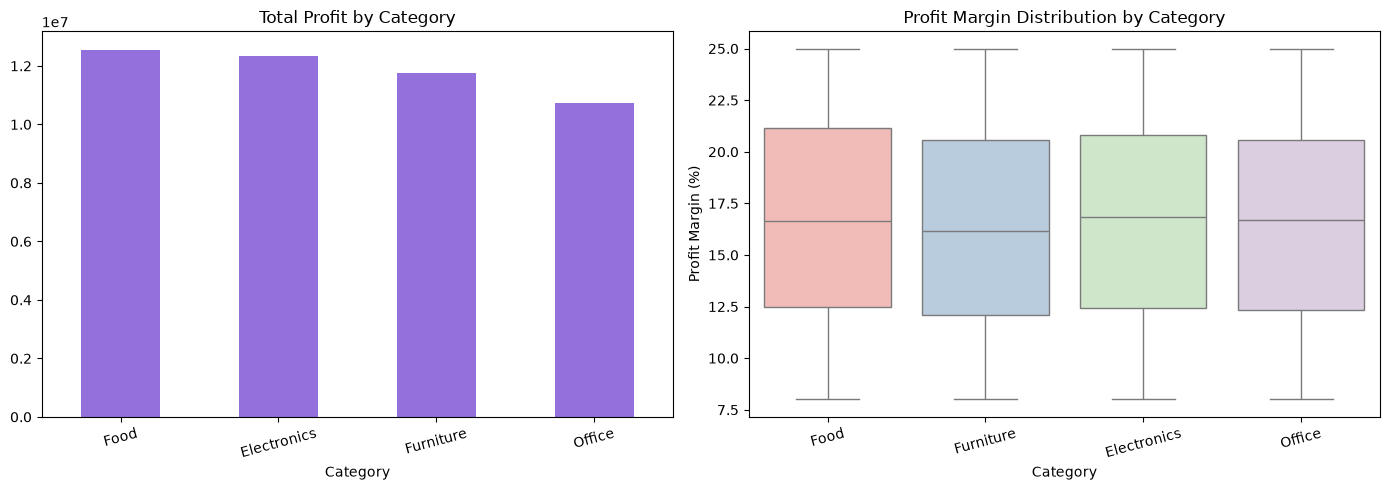

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cat_profit['Total_Profit'].plot(kind='bar', ax=axes[0], color='mediumpurple')
axes[0].set_title('Total Profit by Category')
axes[0].tick_params(axis='x', rotation=15)

sns.boxplot(data=data, x='Category', y='Profit Margin (%)', hue='Category', ax=axes[1], palette='Pastel1', legend=False)
axes[1].set_title('Profit Margin Distribution by Category')
axes[1].tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

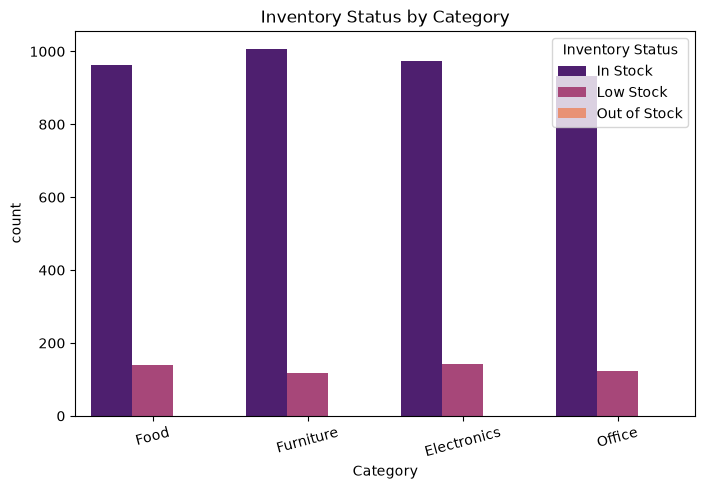

In [37]:
plt.figure(figsize=(8, 5))
sns.countplot(data=data, x='Category', hue='Inventory Status', palette='magma')
plt.title('Inventory Status by Category')
plt.xticks(rotation=15)
plt.show()

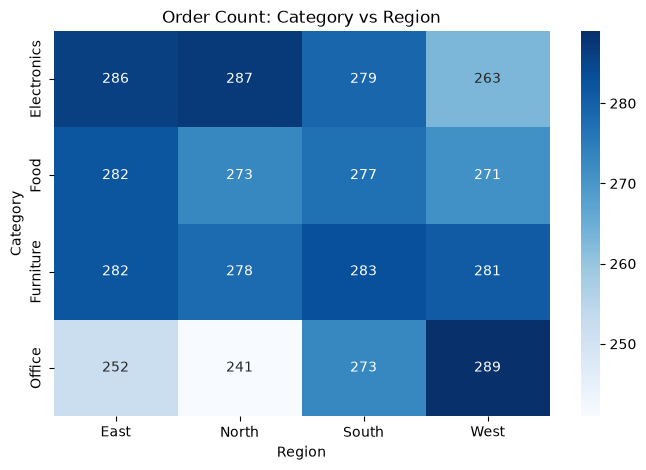

In [49]:
category_region = pd.crosstab(data['Category'], data['Region'])
plt.figure(figsize=(8, 5))
sns.heatmap(category_region, annot=True, fmt='d', cmap='Blues')
plt.title('Order Count: Category vs Region')
plt.show()

In [52]:
region_summary = data.groupby('Region').agg(
    Orders=('Order ID', 'count'),
    Total_Sales=('Sales Amount', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Avg_Delivery_Days=('Delivery Days', 'mean')
).round(1).sort_values('Total_Sales', ascending=False)
region_summary

,Orders,Total_Sales,Total_Profit,Avg_Delivery_Days
Region,,,,
West,1104,73328501,12033579.5,7.0
South,1112,72488721,11858292.1,7.1
East,1102,71866957,11784795.6,6.9
North,1079,69468562,11709873.2,7.0


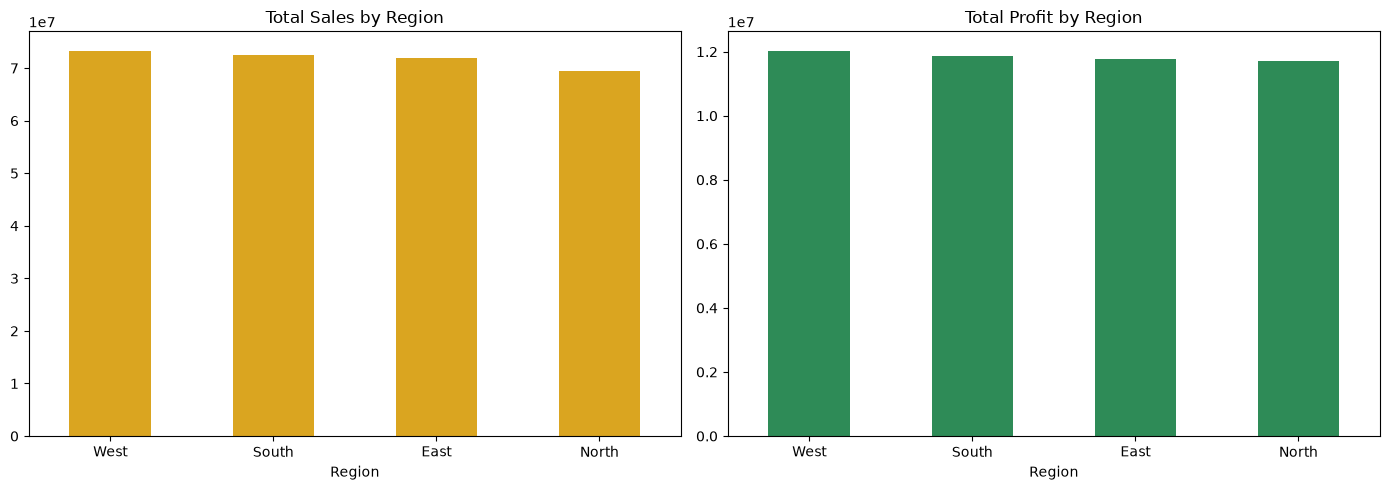

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
region_summary['Total_Sales'].plot(kind='bar', ax=axes[0], color='goldenrod')
axes[0].set_title('Total Sales by Region')
axes[0].tick_params(axis='x', rotation=0)

region_summary['Total_Profit'].plot(kind='bar', ax=axes[1], color='seagreen')
axes[1].set_title('Total Profit by Region')
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()


In [55]:
vendor_summary = data.groupby('Vendor Name').agg(
    Orders=('Order ID', 'count'),
    Avg_Rating=('Vendor Rating', 'mean'),
    Avg_Lead_Time=('Lead Time (Days)', 'mean'),
    On_Time_Rate=('On-Time Delivery', lambda x: (x == 'Yes').mean() * 100),
    Total_Sales=('Sales Amount', 'sum'),
    Total_Profit=('Profit', 'sum')
).sort_values('Total_Profit', ascending=False).round(1)

vendor_summary

,Orders,Avg_Rating,Avg_Lead_Time,On_Time_Rate,Total_Sales,Total_Profit
Vendor Name,,,,,,
Vendor 3,470,4.0,6.1,38.3,30889667,5091043.2
Vendor 8,460,4.0,6.1,39.6,30569458,5022115.4
Vendor 9,448,4.0,5.8,41.3,29850153,4934531.2
Vendor 1,442,4.0,6.1,38.2,29692060,4853251.7
Vendor 5,439,4.0,5.8,38.7,29368140,4831630.7
Vendor 4,462,4.0,6.0,38.1,29427301,4821537.1
Vendor 2,402,4.0,6.0,37.3,27832780,4635603.2
Vendor 10,419,4.0,6.0,35.8,27503478,4509427.2
Vendor 7,447,4.0,6.1,41.6,27210565,4487279.4


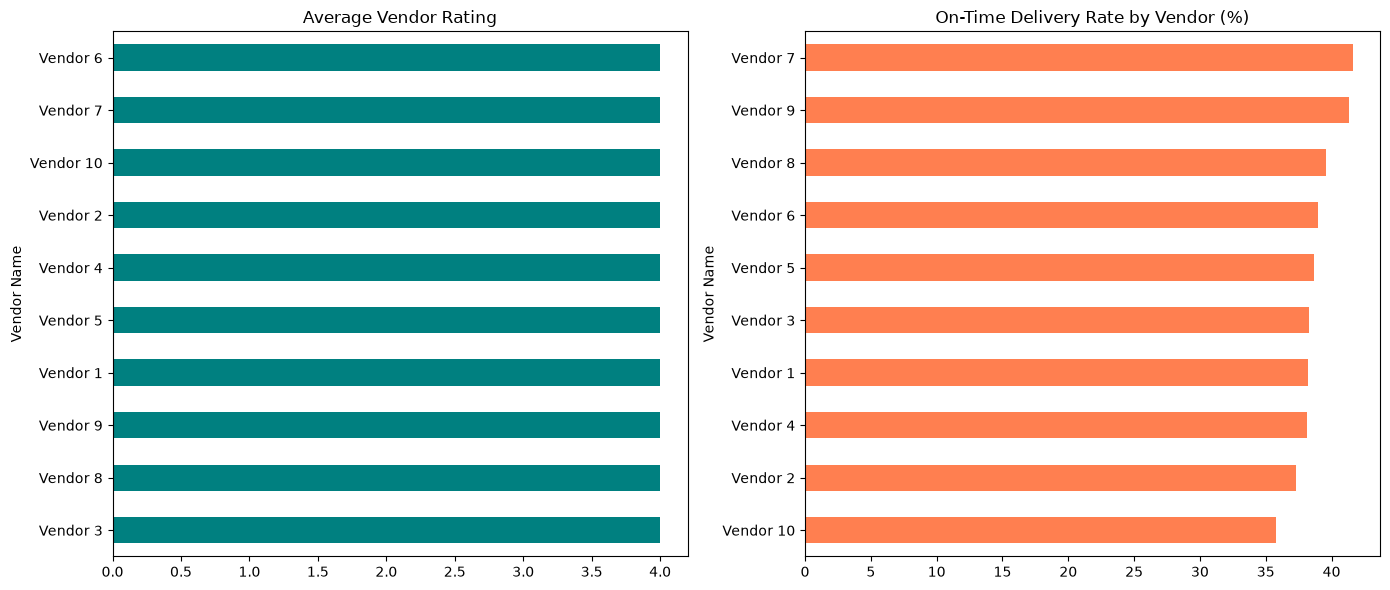

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
vendor_summary['Avg_Rating'].sort_values().plot(kind='barh', ax=axes[0], color='teal')
axes[0].set_title('Average Vendor Rating')

vendor_summary['On_Time_Rate'].sort_values().plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('On-Time Delivery Rate by Vendor (%)')
plt.tight_layout()
plt.show()

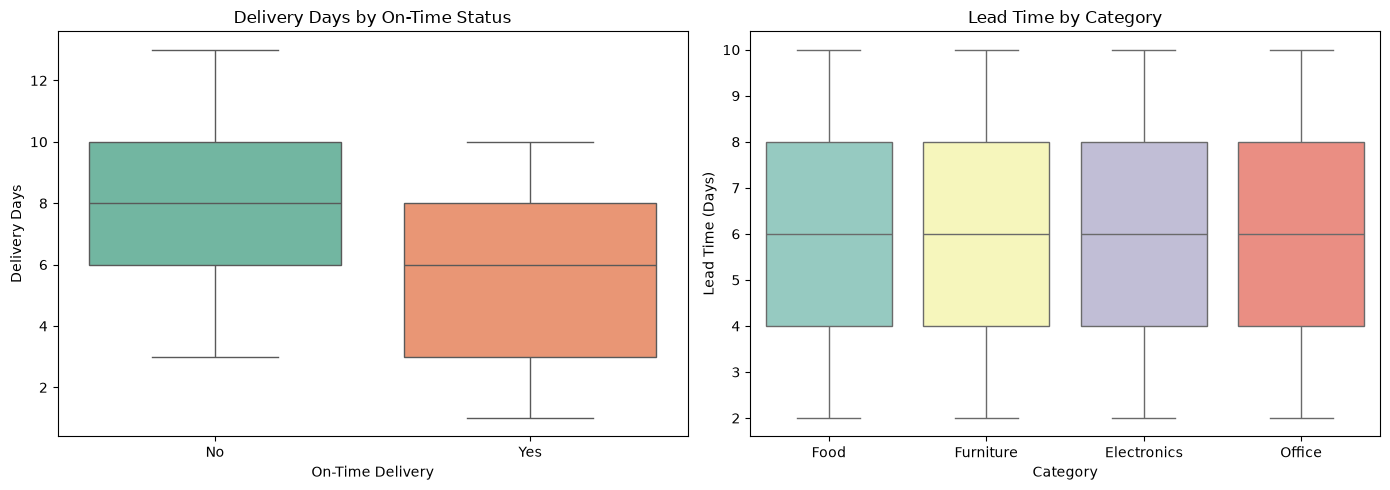

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=data, x='On-Time Delivery', y='Delivery Days', hue='On-Time Delivery', ax=axes[0], palette='Set2', legend=False)
axes[0].set_title('Delivery Days by On-Time Status')

sns.boxplot(data=data, x='Category', y='Lead Time (Days)', hue='Category', ax=axes[1], palette='Set3', legend=False)
axes[1].set_title('Lead Time by Category')
plt.tight_layout()
plt.show()

- **Total Sales: Rs 28,71,52,741 | Total Profit: Rs 4,73,86,540 | Overall Margin: 16.5%**
- On-time delivery rate is only ~38.8% — the majority of orders (61.2%) are delayed, a significant operational concern
- Order Status is split almost evenly — 34.1% Cancelled, 33.1% Delivered, 32.8% Pending — an unusually high cancellation rate worth investigating
- No orders show negative profit — unlike typical retail data, this dataset has no loss-making transactions, which is worth validating against the       data source
- No missing values and no duplicate records — the dataset is clean and ready for further modeling
- Vendor 7 has the best on-time rate (41.6%), while Vendor 10 has the worst (35.8%) — despite both carrying identical average ratings (4.0),             reinforcing that rating alone isn't a good delivery predictor
- **Suggested Next Steps**
- Investigate root causes of delays — 61% delayed is high; break down by lead time bucket, warehouse, or vendor
- Reduce cancellations — a ~34% cancellation rate is unusually high; check if it's tied to stockouts or specific categories
- Revisit vendor scoring — since rating doesn't predict on-time performance, consider adding delivery-based KPIs
- Tighten reorder policies — 12% of orders sit at/below reorder level; review reorder thresholds by category
- Validate the "zero loss orders" finding — confirm this reflects real business rules and isn't a data-generation artifact

